# Day 01 — Part-to-Whole
### #30DayChartChallenge | April 2026

**What kills us?** A waffle chart showing global deaths by cause.  
Each square in a 10×10 grid represents ~1% of 67.9 million deaths worldwide.

**Data:**  
GBD 2021 Causes of Death Collaborators.  
*The Lancet*, 403(10440), 2100–2132. 2024.  
DOI: [10.1016/S0140-6736(24)00367-2](https://doi.org/10.1016/S0140-6736(24)00367-2)  
Source: IHME, University of Washington

**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'showtext' was built under R version 4.5.3"
Loading required package: sysfonts

Warning message:
"package 'sysfonts' was built under R version 4.5.3"
Loading required package: showtextdb

Warning message:
"package 'showtextdb' was built under R version 4.5.3"


In [2]:
# — fonts ---------------------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
showtext_auto()
showtext_opts(dpi = 300)

# set notebook preview to match ggsave dimensions
options(repr.plot.width = 12, repr.plot.height = 11, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------

gbd <- read.csv("../../data/day_01/gbd_2021_global_deaths_by_cause.csv",
                stringsAsFactors = FALSE)

gbd$cause <- factor(gbd$cause, levels = gbd$cause)

head(gbd)

,cause,level1_category,deaths_millions,share_pct,share_pct_rounded
,<fct>,<chr>,<dbl>,<dbl>,<int>
1,Cardiovascular diseases,NCD,19.4,28.6,29
2,Neoplasms (Cancers),NCD,9.9,14.6,15
3,Respiratory infections incl. COVID-19,CMNN,7.5,11.0,11
4,Chronic respiratory diseases,NCD,4.4,6.5,6
5,Diabetes & kidney diseases,NCD,3.1,4.6,5
6,Neurological disorders,NCD,3.0,4.4,4


In [4]:
# — build the waffle grid -----------------------------------------------------
# 10 rows × 10 cols = 100 cells. Each cell ≈ 1%.

vals <- rep(gbd$cause, gbd$share_pct_rounded)

waffle_df <- data.frame(
  cause = factor(vals, levels = levels(gbd$cause)),
  x     = rep(1:10, 10),
  y     = rep(10:1, each = 10)
)

In [5]:
# — colors & labels -----------------------------------------------------------

bg      <- "#0D1117"
txt     <- "#E6EDF3"
txt_dim <- "#8B949E"
txt_cap <- "#484F58"

pal <- c(
  "Cardiovascular diseases"                = "#E63946",
  "Neoplasms (Cancers)"                    = "#9B59B6",
  "Respiratory infections incl. COVID-19"  = "#E67E22",
  "Chronic respiratory diseases"           = "#1ABC9C",
  "Diabetes & kidney diseases"             = "#F1C40F",
  "Neurological disorders"                 = "#3498DB",
  "Digestive diseases"                     = "#2ECC71",
  "Injuries"                               = "#E74C3C",
  "Neonatal disorders"                     = "#FF6B9D",
  "Other causes"                           = "#566573"
)

legend_labs <- setNames(
  paste0(gbd$cause, "  (", gbd$share_pct_rounded, "% \u00b7 ",
         gbd$deaths_millions, "M)"),
  gbd$cause
)

# how much of the total is non-communicable disease?
ncd_pct  <- sum(gbd$share_pct_rounded[gbd$level1_category == "NCD"])
rest_pct <- 100 - ncd_pct

cat("NCD:", ncd_pct, "%  |  Infections, injuries & other:", rest_pct, "%\n")

NCD: 63 %  |  Infections, injuries & other: 37 %


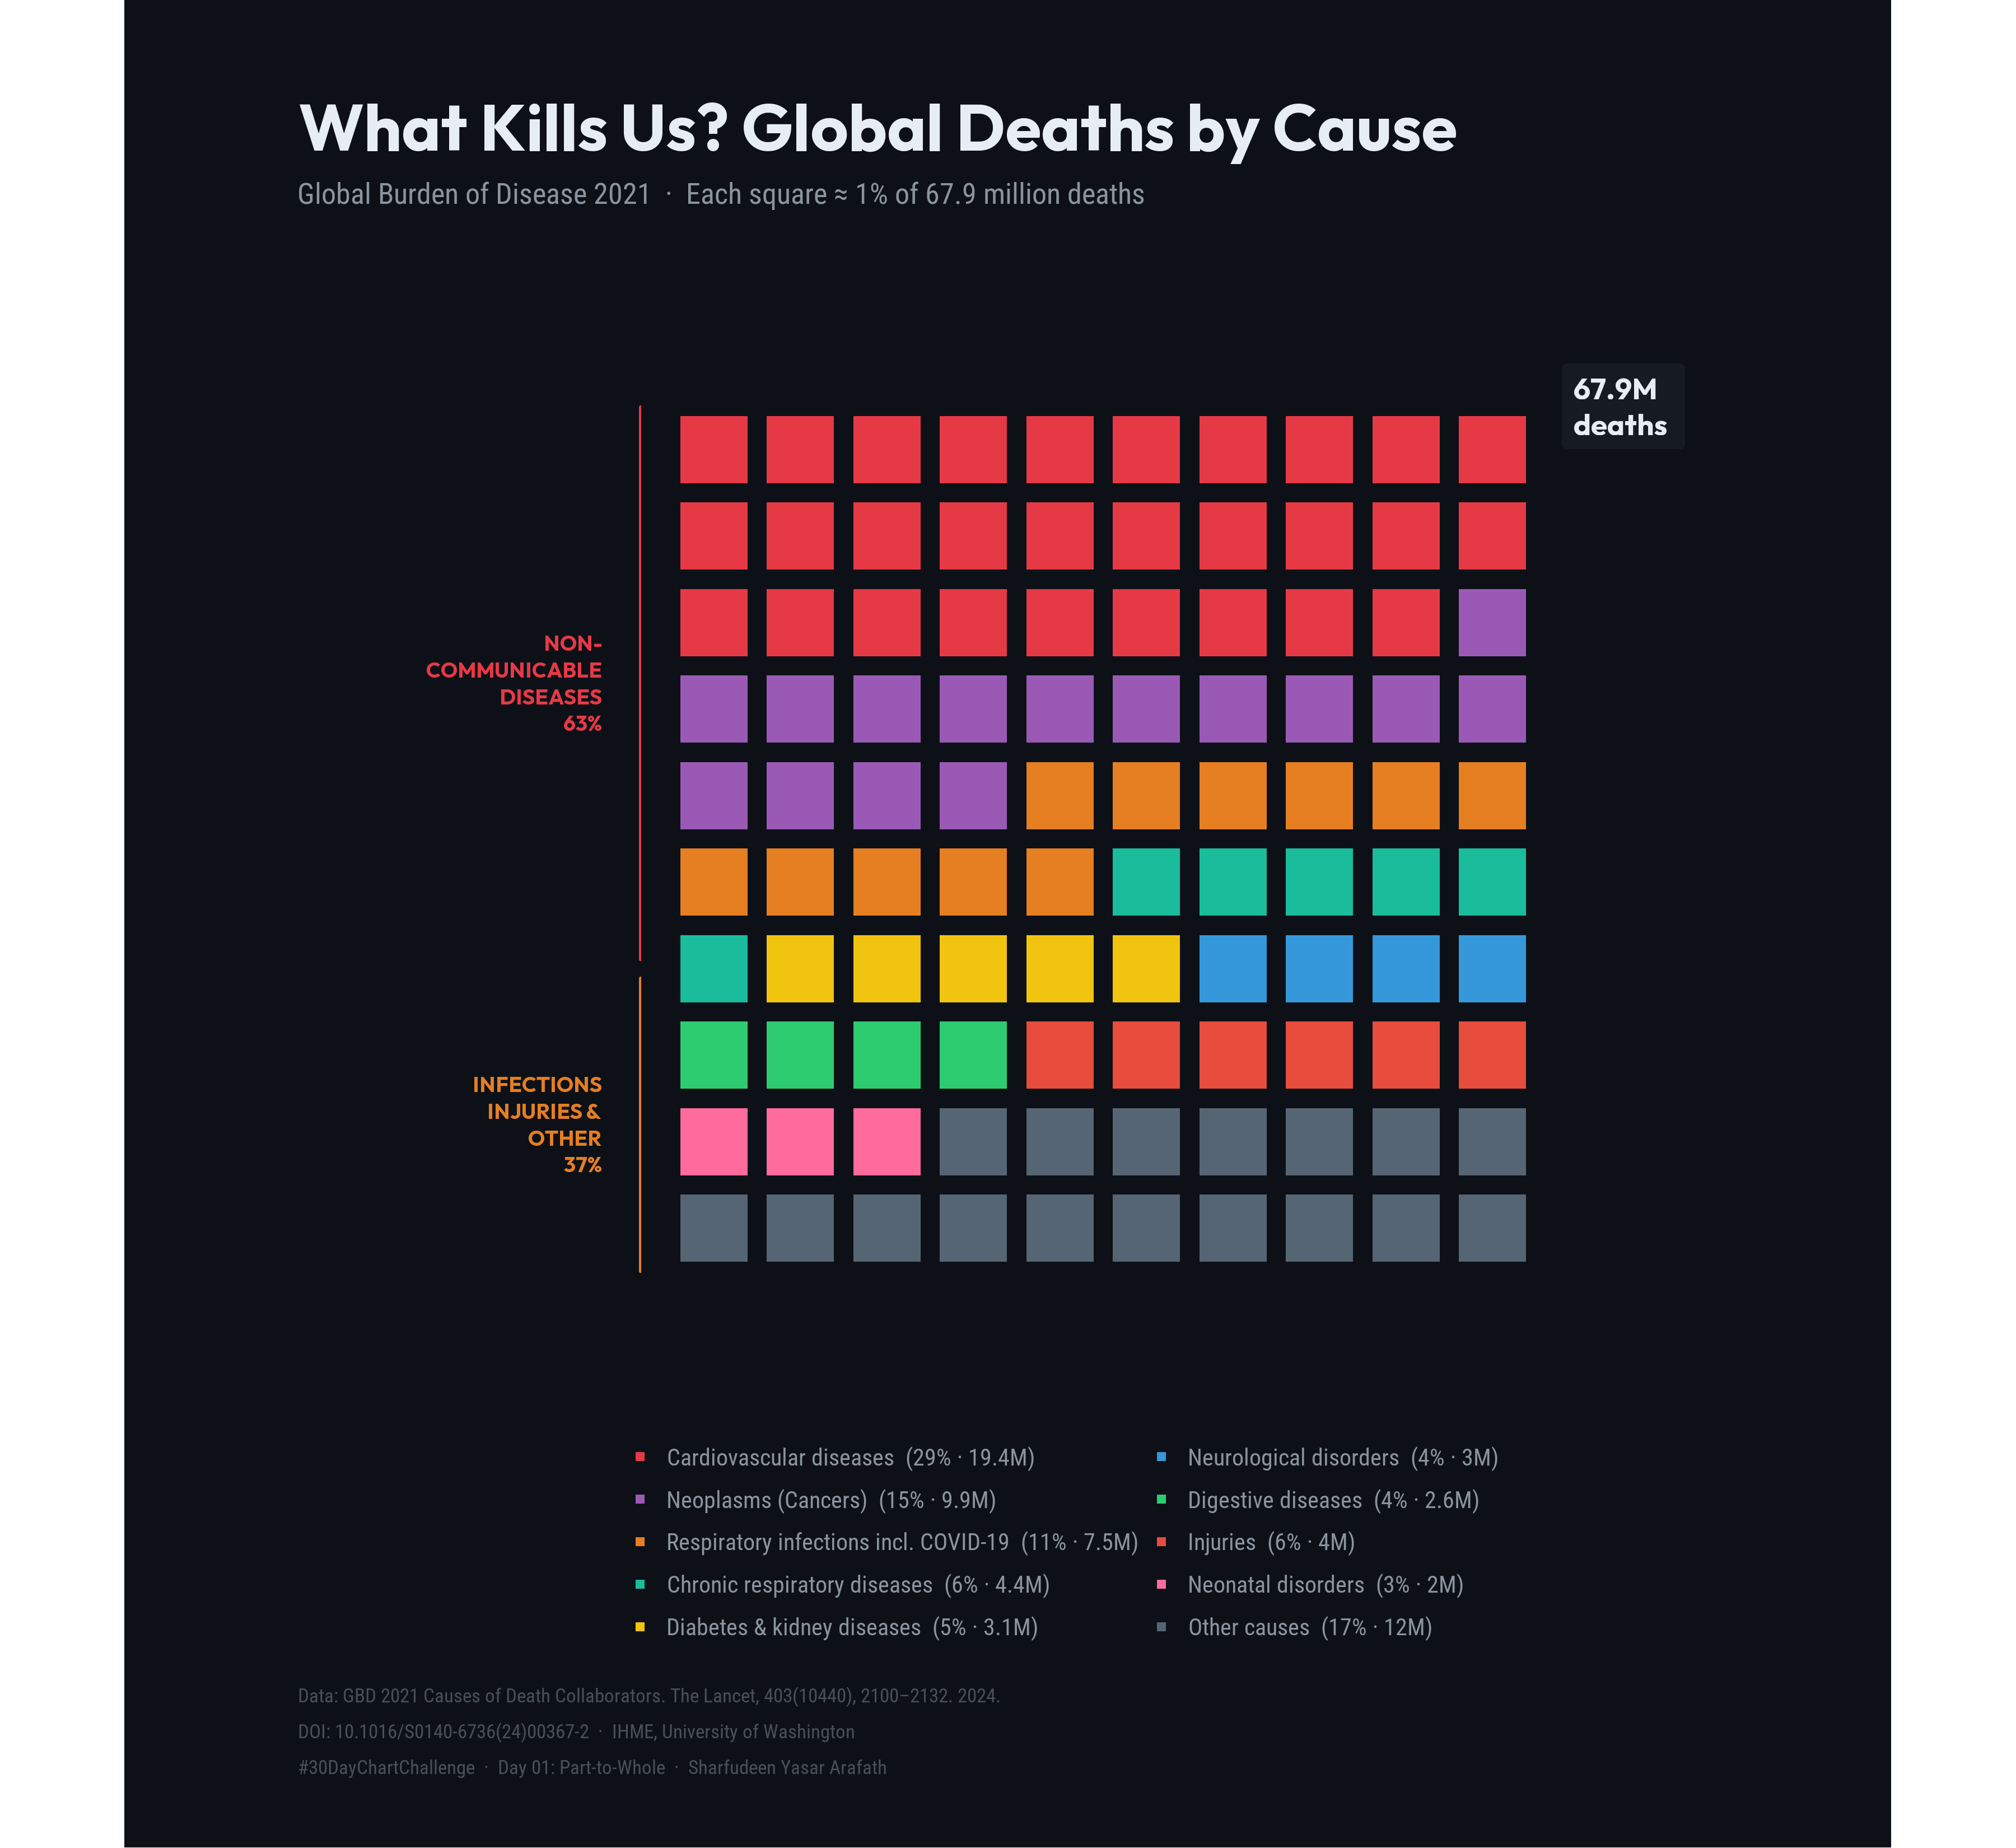

In [6]:
# — plot ----------------------------------------------------------------------

p <- ggplot(waffle_df, aes(x, y, fill = cause)) +

  geom_tile(color = bg, linewidth = 1.8,
            width = 0.88, height = 0.88) +

  # left-side bracket: NCDs
  annotate("segment", x = 0.15, xend = 0.15, y = 4.1, yend = 10.5,
           color = "#E63946", linewidth = 0.5, lineend = "round") +
  annotate("text", x = -0.3, y = 7.3,
           label = paste0("NON-\nCOMMUNICABLE\nDISEASES\n", ncd_pct, "%"),
           color = "#E63946", family = "outfit", fontface = "bold",
           size = 3.2, hjust = 1, lineheight = 1.05) +

  # left-side bracket: infections + injuries + other
  annotate("segment", x = 0.15, xend = 0.15, y = 0.5, yend = 3.9,
           color = "#E67E22", linewidth = 0.5, lineend = "round") +
  annotate("text", x = -0.3, y = 2.2,
           label = paste0("INFECTIONS\nINJURIES &\nOTHER\n", rest_pct, "%"),
           color = "#E67E22", family = "outfit", fontface = "bold",
           size = 3.2, hjust = 1, lineheight = 1.05) +

  # total deaths callout
  annotate("label", x = 10.8, y = 10.5,
           label = "67.9M\ndeaths",
           color = txt, fill = "#161B22",
           family = "outfit", fontface = "bold",
           size = 4.5, hjust = 0, lineheight = 1,
           linewidth = 0, label.padding = unit(0.4, "lines")) +

  scale_fill_manual(values = pal, labels = legend_labs, name = NULL) +
  scale_x_continuous(limits = c(-3, 13)) +
  scale_y_continuous(limits = c(-0.5, 11.5)) +
  coord_equal(clip = "off") +

  labs(
    title    = "What Kills Us? Global Deaths by Cause",
    subtitle = "Global Burden of Disease 2021  \u00b7  Each square \u2248 1% of 67.9 million deaths",
    caption  = paste0(
      "Data: GBD 2021 Causes of Death Collaborators. ",
      "The Lancet, 403(10440), 2100\u20132132. 2024.\n",
      "DOI: 10.1016/S0140-6736(24)00367-2  \u00b7  ",
      "IHME, University of Washington\n",
      "#30DayChartChallenge  \u00b7  Day 01: Part-to-Whole  \u00b7  Sharfudeen Yasar Arafath"
    )
  ) +

  theme_void(base_family = "roboto_condensed") +
  theme(
    plot.title       = element_text(family = "outfit", face = "bold", size = 28,
                                    hjust = 0, color = txt,
                                    margin = margin(t = 20, b = 8)),
    plot.subtitle    = element_text(size = 12.5, hjust = 0, color = txt_dim,
                                    margin = margin(b = 25)),
    plot.caption     = element_text(size = 8.5, hjust = 0, color = txt_cap,
                                    margin = margin(t = 20, b = 10),
                                    lineheight = 1.5),
    legend.position  = "bottom",
    legend.text      = element_text(size = 10, color = txt_dim),
    legend.key.size  = unit(0.45, "cm"),
    legend.spacing.x = unit(0.3, "cm"),
    legend.margin    = margin(t = 8),
    plot.background  = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin      = margin(25, 30, 20, 75)
  ) +
  guides(fill = guide_legend(nrow = 5, byrow = FALSE))

p

In [7]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_01_part_to_whole.png",
       plot = p, width = 12, height = 11, dpi = 300, bg = bg)

cat("Done — saved to chart/day_01_part_to_whole.png\n")

Done — saved to chart/day_01_part_to_whole.png
